## Description:
建立Wide&Deep Model在cretio数据集上进行点击率预测的任务

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import datetime
import pickle

import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

from torchkeras import summary, Model

from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [9]:
import torch
print(torch.__version__)

2.1.2.post104


In [10]:
import torchkeras
print(torchkeras.__file__)
print(torchkeras.__version__)

/opt/anaconda3/envs/torch/lib/python3.8/site-packages/torchkeras/__init__.py
2.1.2


## 数据准备

In [11]:
file_path = './preprocessed_data/'

In [135]:
def prepared_data(file_path):
    #读入训练集、验证集、测试集
    train = pd.read_csv(file_path + 'train_set.csv')
    test = pd.read_csv(file_path + 'test_set.csv')
    val = pd.read_csv(file_path + 'val_set.csv')

    trn_x, trn_y = train.drop(columns='Label').values,  train['Label'].values
    val_x, val_y = val.drop(columns='Label').values, val['Label'].values
    test_x = test.values

    # fea_col = np.load(file_path + 'fea_col.npy', allow_pickle=True)
    with open('preprocessed_data/fea_col.pkl', 'rb') as f:
        fea_col = pickle.load(f)  # 加载对象列表
    return fea_col, (trn_x, trn_y), (val_x, val_y), test_x

In [136]:
fea_cols, (trn_x, trn_y), (val_x, val_y), test_x = prepared_data(file_path)

In [137]:
test_x.shape

(400, 39)

In [47]:
#将数据构造成数据管道
dl_train_dataset = TensorDataset(torch.tensor(trn_x, dtype=torch.float), torch.tensor(trn_y, dtype=torch.float))
dl_val_dataset = TensorDataset(torch.tensor(val_x).float(), torch.tensor(val_y).float())

dl_train = DataLoader(dl_train_dataset, batch_size=32, shuffle=True)
dl_val = DataLoader(dl_val_dataset, batch_size=32, shuffle=True)

In [48]:
# 看一下数据
for b in iter(dl_train):
    print(b[0].shape, b[1].shape, b[1])
    break

torch.Size([32, 39]) torch.Size([32]) tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1.])


In [138]:
fea_cols

[[{'feat': 'I1'},
  {'feat': 'I2'},
  {'feat': 'I3'},
  {'feat': 'I4'},
  {'feat': 'I5'},
  {'feat': 'I6'},
  {'feat': 'I7'},
  {'feat': 'I8'},
  {'feat': 'I9'},
  {'feat': 'I10'},
  {'feat': 'I11'},
  {'feat': 'I12'},
  {'feat': 'I13'}],
 [{'feat': 'C1', 'feat_num': 79, 'embed_dim': 8},
  {'feat': 'C2', 'feat_num': 252, 'embed_dim': 8},
  {'feat': 'C3', 'feat_num': 1293, 'embed_dim': 8},
  {'feat': 'C4', 'feat_num': 1043, 'embed_dim': 8},
  {'feat': 'C5', 'feat_num': 30, 'embed_dim': 8},
  {'feat': 'C6', 'feat_num': 7, 'embed_dim': 8},
  {'feat': 'C7', 'feat_num': 1164, 'embed_dim': 8},
  {'feat': 'C8', 'feat_num': 39, 'embed_dim': 8},
  {'feat': 'C9', 'feat_num': 2, 'embed_dim': 8},
  {'feat': 'C10', 'feat_num': 908, 'embed_dim': 8},
  {'feat': 'C11', 'feat_num': 926, 'embed_dim': 8},
  {'feat': 'C12', 'feat_num': 1239, 'embed_dim': 8},
  {'feat': 'C13', 'feat_num': 824, 'embed_dim': 8},
  {'feat': 'C14', 'feat_num': 20, 'embed_dim': 8},
  {'feat': 'C15', 'feat_num': 819, 'embed_dim'

In [130]:
fea_col_true = np.load('/Users/home/chenxing/pyCharmProject/AI-RecommenderSystem/Rank/WideDeep/preprocessed_data/fea_col.npy', allow_pickle=True)
fea_col_true

array([list([{'feat': 'I1'}, {'feat': 'I2'}, {'feat': 'I3'}, {'feat': 'I4'}, {'feat': 'I5'}, {'feat': 'I6'}, {'feat': 'I7'}, {'feat': 'I8'}, {'feat': 'I9'}, {'feat': 'I10'}, {'feat': 'I11'}, {'feat': 'I12'}, {'feat': 'I13'}]),
       list([{'feat': 'C1', 'feat_num': 79, 'embed_dim': 8}, {'feat': 'C2', 'feat_num': 252, 'embed_dim': 8}, {'feat': 'C3', 'feat_num': 1293, 'embed_dim': 8}, {'feat': 'C4', 'feat_num': 1043, 'embed_dim': 8}, {'feat': 'C5', 'feat_num': 30, 'embed_dim': 8}, {'feat': 'C6', 'feat_num': 7, 'embed_dim': 8}, {'feat': 'C7', 'feat_num': 1164, 'embed_dim': 8}, {'feat': 'C8', 'feat_num': 39, 'embed_dim': 8}, {'feat': 'C9', 'feat_num': 2, 'embed_dim': 8}, {'feat': 'C10', 'feat_num': 908, 'embed_dim': 8}, {'feat': 'C11', 'feat_num': 926, 'embed_dim': 8}, {'feat': 'C12', 'feat_num': 1239, 'embed_dim': 8}, {'feat': 'C13', 'feat_num': 824, 'embed_dim': 8}, {'feat': 'C14', 'feat_num': 20, 'embed_dim': 8}, {'feat': 'C15', 'feat_num': 819, 'embed_dim': 8}, {'feat': 'C16', 'feat_n

# 构建模型
这里依然是使用继承nn.Module基类构建模型， 并辅助应用模型容器进行封装， Wide&Deep的模型结构如下：

这个模型搭建起来，相对比较简单， 主要分为wide部分， Deep部分和两者的拼接

In [139]:
class Linear(nn.Module):
    # linear part
    def __init__(self, input_dim):
        super(Linear, self).__init__()
        self.linear = nn.Linear(in_features=input_dim, out_features=1)
    def forward(self, x):
        return self.linear(x)

class Dnn(nn.Module):
    # Dnn part
    def __init__(self, hidden_units, dropout=0.0):
        """
        hidden_units: 列表， 每个元素表示每一层的神经单元个数， 比如[256, 128, 64], 两层网络， 第一层神经单元128， 第二层64， 第一个维度是输入维度
        dropout: 失活率
        """
        super(Dnn, self).__init__()
        self.dnn_network = nn.ModuleList([nn.Linear(layer[0], layer[1]) for layer in list(zip(hidden_units[:-1], hidden_units[1:]))])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        for linear in self.dnn_network:
            x = linear(x)
            x = F.relu(x)
        x = self.dropout(x)
        return x


In [150]:
class WideDeep(nn.Module):
    def __init__(self, feature_columns, hidden_units, dropout=0.0):
        super(WideDeep, self).__init__()
        self.dense_feature_columns, self.sparse_feature_columns = feature_columns

        # embedding
        self.embed_layers = nn.ModuleDict({
            'embed_' + str(i): nn.Embedding(num_embeddings=feat['feat_num'], embedding_dim=feat['embed_dim'])
            for i, feat in enumerate(self.sparse_feature_columns)
        })

        '''
        等价写法
        self.embed_layer = nn.ModuleDict()
        for i, feat in enumerate(self.sparse_feature_columns):
            embed_name = 'embed_' + str(i)
            self.embed_layer[embed_name] = nn.Embedding(
                num_embeddings=feat['feat_num'],
                embedding_dim=feat['embed_dim']
            )
        '''

        # 在首位插入mlp网络第一层的数量
        hidden_units.insert(0, len(self.dense_feature_columns) + len(self.sparse_feature_columns) * self.sparse_feature_columns[0]['embed_dim'])
        print(hidden_units)
        self.dnn_network = Dnn(hidden_units)
        self.linear = Linear(len(self.dense_feature_columns))
        self.final_linear = nn.Linear(hidden_units[-1], 1) # deep结构输出层

    def forward(self, x):
        dense_input = x[:, :len(self.dense_feature_columns)]
        sparse_inputs = x[:, len(self.dense_feature_columns):]
        sparse_inputs = sparse_inputs.long()

        # for i in range(sparse_inputs.shape[1]):
        #     # 打印当前特征列i的最大索引
        #     max_idx = sparse_inputs[:, i].max().item()
        #     # 打印对应嵌入层的num_embeddings
        #     embed_layer = self.embed_layers['embed_'+str(i)]
        #     num_embed = embed_layer.num_embeddings
        #     print(f"特征列{i}：最大索引={max_idx}，嵌入层容量={num_embed}")
        #     if max_idx >= num_embed:
        #         print(f"❌ 特征列{i}索引越界：max_idx={max_idx} ≥ num_embeddings={num_embed}")

        sparse_embeds = [self.embed_layers['embed_'+str(i)](sparse_inputs[:, i]) for i in range(sparse_inputs.shape[1])]
        sparse_embeds = torch.cat(sparse_embeds, dim=-1) #将多个张量在指定维度上连接，生成一个更大的张量。输入是[batch_size, embed_dim]的list
        # 在forward方法中临时添加调试代码
        sparse_inputs = x[:, len(self.dense_feature_columns):]
        sparse_inputs = sparse_inputs.long()
        '''
        sparse_embeds = []
        for i in range(sparse_inputs.shape[1]):
            embed_name = 'embed_' + str(i)  # 例如：'embed_0'
            embed_layer = self.embed_layers[embed_name]  # 获取第i个特征对应的嵌入层
            column_i = sparse_inputs[:, i]  # 提取输入的第i列（形状：[batch_size]）
            embed_vector = embed_layer(column_i)  # 将列转换为嵌入向量（形状：[batch_size, embed_dim]）
            sparse_embeds.append(embed_vector)  # 添加到列表
        '''
        dnn_input = torch.cat([dense_input, sparse_embeds], dim=-1) #dnn_input的输入是稀疏向量合并稠密向量

        #wide
        wide_out = self.linear(dense_input)

        #deep
        deep_out = self.dnn_network(dnn_input)
        deep_out = self.final_linear(deep_out)

        #out
        outputs = F.sigmoid(0.5 * (wide_out + deep_out))
        outputs = outputs.squeeze(1)  # 压缩为 [batch_size]

        return outputs


In [156]:
# 建立模型
hidden_units = [256, 128, 64]
dnn_dropout = 0.0
model = WideDeep(fea_cols, hidden_units, dnn_dropout)
summary(model, input_shape = (trn_x.shape[1], ))    #在 Python 中，创建单元素元组时必须使用逗号，否则括号会被解释为数学表达式

[221, 256, 128, 64]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Embedding-1                    [-1, 8]             632
         Embedding-2                    [-1, 8]           2,016
         Embedding-3                    [-1, 8]          10,344
         Embedding-4                    [-1, 8]           8,344
         Embedding-5                    [-1, 8]             240
         Embedding-6                    [-1, 8]              56
         Embedding-7                    [-1, 8]           9,312
         Embedding-8                    [-1, 8]             312
         Embedding-9                    [-1, 8]              16
        Embedding-10                    [-1, 8]           7,264
        Embedding-11                    [-1, 8]           7,408
        Embedding-12                    [-1, 8]           9,912
        Embedding-13                    [-1, 8]           6,592
        Embedding-1

# 模型训练

In [157]:
# 模型的相关设置
def auc(y_pred, y_true):
    pred = y_pred.data
    y = y_true.data
    return roc_auc_score(y, pred)

loss_func = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
metric_func = auc
metric_name = 'auc'

In [158]:
# 脚本训练风格
epochs = 10
log_step_freq = 10

dfhistory = pd.DataFrame(columns=['epoch', 'loss', metric_name, 'val_loss', 'val_'+metric_name])

print('start_training.........')
nowtime = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print('========'*8 + '%s' %nowtime)

for epoch in range(1, epochs + 1):
    # 训练阶段
    model.train()
    loss_sum = 0.0
    metric_sum = 0.0
    step = 1

    for step, (features, labels) in enumerate(dl_train, 1):
        #梯度清零
        optimizer.zero_grad()

        #正向传播
        predictions = model(features)
        loss = loss_func(predictions, labels)
        try:
            metric = metric_func(predictions, labels)
        except ValueError:
            pass
        #反向传播
        loss.backward()
        optimizer.step()

        #打印batch级别日志
        loss_sum += loss.item()
        metric_sum += metric.item()
        if step % log_step_freq == 0:
            print(("[step=%d] loss: %.3f, " + metric_name + ": %.3f") % (step, loss_sum/step, metric_sum/step))

    #验证阶段
    model.eval()
    val_loss_sum = 0.0
    val_metric_sum = 0.0
    val_step = 1

    for val_step, (features, labels) in enumerate(dl_val, 1):
        with torch.no_grad():
            predictions = model(features)
            val_loss = loss_func(predictions, labels)
            try:
                val_metric = metric_func(predictions, labels)
            except ValueError:
                pass
        val_loss_sum += val_loss.item()
        val_metric_sum += val_metric.item()

    #记录日志
    info = (epoch, loss_sum/step, metric_sum/step, val_loss_sum/val_step, val_metric_sum/val_step)
    dfhistory.loc[epoch-1] = info

    # 打印日志
    print(("\nEPOCH=%d, loss=%.3f, " + metric_name + " = %.3f, val_loss=%.3f, " + "val_" + metric_name + " = %.3f") %info)
    nowtime = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print('\n' + '=========='* 8 + '%s' %nowtime)
print('Finished Training')


start_training.........
================================================================2025-07-20 19:13:08
[step=10] loss: 0.594, auc: 0.604
[step=20] loss: 0.560, auc: 0.558
[step=30] loss: 0.554, auc: 0.560
[step=40] loss: 0.551, auc: 0.567

EPOCH=1, loss=0.551, auc = 0.567, val_loss=0.447, val_auc = 0.642

================================================================================2025-07-20 19:13:08
[step=10] loss: 0.475, auc: 0.733
[step=20] loss: 0.468, auc: 0.761
[step=30] loss: 0.477, auc: 0.756
[step=40] loss: 0.473, auc: 0.765

EPOCH=2, loss=0.473, auc = 0.765, val_loss=0.423, val_auc = 0.667

================================================================================2025-07-20 19:13:08
[step=10] loss: 0.451, auc: 0.801
[step=20] loss: 0.442, auc: 0.797
[step=30] loss: 0.431, auc: 0.815
[step=40] loss: 0.422, auc: 0.824

EPOCH=3, loss=0.422, auc = 0.824, val_loss=0.430, val_auc = 0.712

================================================================================

In [159]:
dfhistory

,epoch,loss,auc,val_loss,val_auc
0,1.0,0.550575,0.566643,0.446927,0.642058
1,2.0,0.473429,0.765144,0.422962,0.666763
2,3.0,0.421925,0.824165,0.430368,0.712202
3,4.0,0.352825,0.909007,0.455910,0.661198
4,5.0,0.218724,0.973073,0.673275,0.639688
5,6.0,0.094896,0.995600,0.819436,0.685117
6,7.0,0.036698,0.998159,1.028595,0.651995
7,8.0,0.021844,0.999376,0.989283,0.684186
8,9.0,0.008377,1.000000,1.214729,0.669009
9,10.0,0.001934,1.000000,1.277941,0.671647


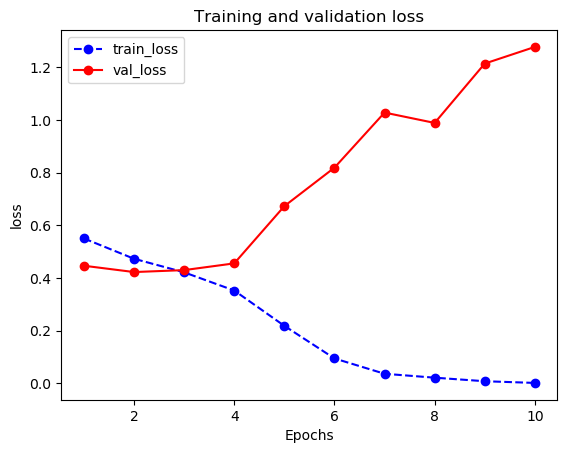

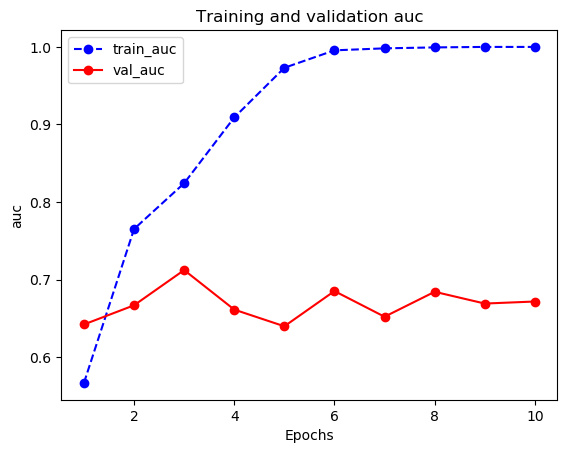

In [164]:
def plot_metric(dfhistory, metric):
    train_metrics = dfhistory[metric].values
    val_metrics = dfhistory['val_'+metric].values
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, 'bo--')
    plt.plot(epochs, val_metrics, 'ro-')
    plt.title('Training and validation '+ metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train_"+metric, 'val_'+metric])
    plt.show()


# 观察损失和准确率的变化
plot_metric(dfhistory,"loss")
plot_metric(dfhistory,"auc")

In [170]:
#预测
y_pred_probs = model(torch.tensor(test_x).float())
y_pred = torch.where(y_pred_probs >= 0.5, 1, 0)

In [174]:
y_pred

tensor([1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [165]:
torch.tensor(test_x).float()

tensor([[0.0000e+00, 1.2713e-04, 0.0000e+00,  ..., 5.1100e+02, 2.3000e+01,
         2.3000e+01],
        [0.0000e+00, 1.2713e-04, 0.0000e+00,  ..., 1.4500e+02, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 2.5426e-04, 2.3649e-04,  ..., 1.7500e+02, 2.0000e+00,
         1.5000e+02],
        ...,
        [0.0000e+00, 3.8393e-02, 4.7298e-04,  ..., 6.7000e+01, 2.7000e+01,
         9.1000e+01],
        [1.0526e-02, 3.8139e-04, 2.3649e-04,  ..., 2.5300e+02, 3.0000e+00,
         2.3800e+02],
        [0.0000e+00, 5.0852e-04, 0.0000e+00,  ..., 5.3100e+02, 0.0000e+00,
         0.0000e+00]])

In [68]:
sparse_inputs = torch.tensor([
    [1, 3],  # 第1个样本的两个特征
    [2, 0],  # 第2个样本的两个特征
])
sparse_inputs.shape

torch.Size([2, 2])

In [79]:
tensor_list = [torch.randn(4, 3), torch.randn(4, 3)]
print(tensor_list)
torch.cat(tensor_list, dim=1)

[tensor([[-1.8512,  0.6564,  1.3553],
        [ 0.5765, -1.3525,  0.0673],
        [-0.6237, -1.3800, -0.5621],
        [ 1.6248, -0.3606, -0.5060]]), tensor([[ 1.6979,  0.6652,  0.2257],
        [-1.1664, -1.0846, -0.9706],
        [-1.4470, -0.3267,  0.5016],
        [-0.7828, -0.2576,  0.6634]])]


tensor([[-1.8512,  0.6564,  1.3553,  1.6979,  0.6652,  0.2257],
        [ 0.5765, -1.3525,  0.0673, -1.1664, -1.0846, -0.9706],
        [-0.6237, -1.3800, -0.5621, -1.4470, -0.3267,  0.5016],
        [ 1.6248, -0.3606, -0.5060, -0.7828, -0.2576,  0.6634]])